## Problem Statement

Goal: Predict whether a customer will churn (Yes/No) using historical customer data.

Problem Type: Binary Classification.

## Importing the dependenicies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

## Load the data + Basic Checks

In [3]:
data = pd.read_csv("dataset/Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# data["TotalCharges"] = data["TotalCharges"].astype(float)
data[data["TotalCharges"]==' ']["tenure"]

488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64

In [8]:
len(data[data["TotalCharges"]==' '])

11

In [9]:
data["TotalCharges"] = data["TotalCharges"].replace({' ': '0.0'})

In [10]:
data["TotalCharges"] = data["TotalCharges"].astype(float)

In [11]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### Target Distribution

The dataset contains both churn and non-churn customers.

Checking the class distribution helps determine whether the dataset is imbalanced.  
In this case, around **73% of customers did not churn** and **27% churned**.

This indicates a **moderate class imbalance**, meaning that relying only on accuracy could be misleading. Therefore, additional metrics such as **precision, recall, and F1 score** will be used to evaluate model performance.

## EDA

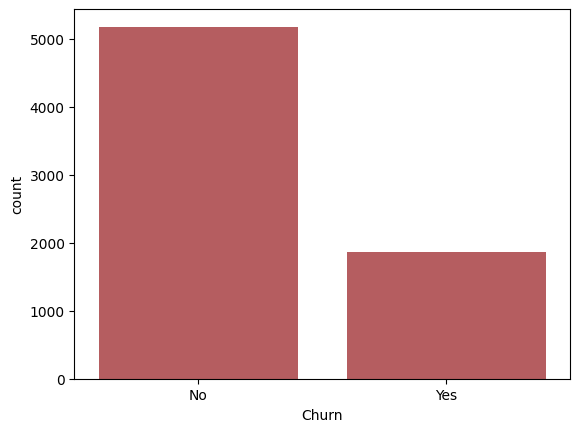

In [12]:
sns.countplot(x="Churn", data=data, color="#C44E52")
plt.show()

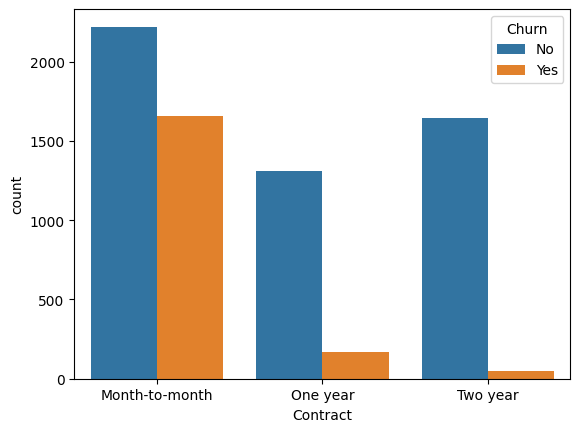

In [13]:
sns.countplot(x="Contract", hue="Churn", data=data)
plt.show()

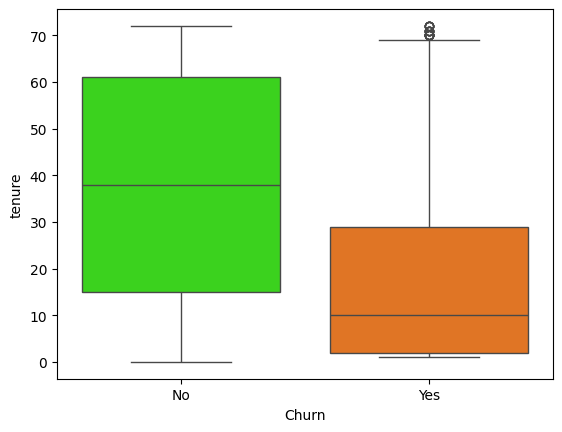

In [14]:
sns.boxplot(x="Churn", y="tenure", data=data, hue="Churn", palette="gist_ncar")
plt.show()

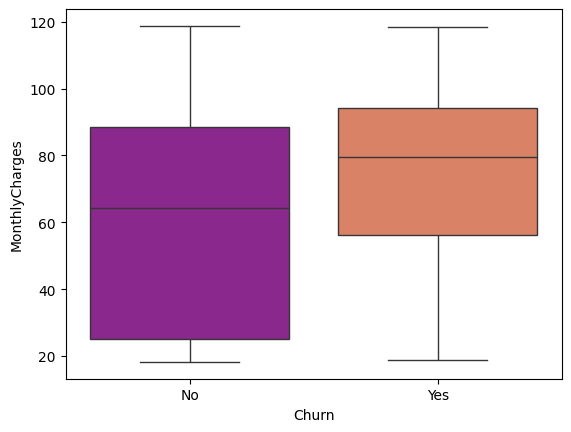

In [15]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=data, hue="Churn",palette="plasma")
plt.show()

### Key Observations from EDA

1. **Contract Type**
   - Customers with **month-to-month contracts** have significantly higher churn rates.
   - Long-term contracts (one year / two year) show much lower churn.

2. **Tenure**
   - Customers with **low tenure tend to churn more frequently**.
   - Long-term customers are more likely to stay.

3. **Monthly Charges**
   - Customers paying **higher monthly charges show slightly higher churn rates**.

These patterns suggest that **customer commitment (contract length) and early customer lifecycle stages** are strong churn indicators.

## Define Features and Target

In [16]:
X = data.drop("Churn", axis=1)
y = data["Churn"].map({"No": 0, "Yes": 1})
X.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [17]:
X = X.drop(columns="customerID")
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


## Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


### Train-Test Split

The dataset was split into **training (80%)** and **testing (20%)** sets.

The `stratify` parameter was used to ensure that the **class distribution of churn vs non-churn remains consistent** in both training and testing datasets.

This helps ensure that the model evaluation is reliable and representative of real-world performance.

## Pipeline

In [20]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)


In [22]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))
    ]
)

## Train Model

In [23]:
model.fit(X_train, y_train)

train_pred = model.predict(X_train)

test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)


In [24]:
print("Train accuracy: ", train_acc)
print("Test accuracy: ", test_acc)

Train accuracy:  0.7525736599219027
Test accuracy:  0.7381121362668559


In [25]:
print("Accuracy: ", accuracy_score(y_test, test_pred))
print("\nclassification_report: ", classification_report(y_test, test_pred))
print("\nConfusion Matrix: ", confusion_matrix(y_test, test_pred))



Accuracy:  0.7381121362668559

classification_report:                precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Confusion Matrix:  [[747 288]
 [ 81 293]]


### Logistic Regression with Class Balancing

To address the class imbalance, the model was trained with:

class_weight = 'balanced'

This forces the algorithm to give **more importance to the minority class (churn customers)**.

Results:

- Recall for churn increased significantly to **0.78**
- Accuracy decreased slightly to **~74%**

Although accuracy dropped, the model now **detects far more churn customers**, which is often more valuable for retention strategies.

## Cross Validation

In [ ]:
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="recall"
)


In [27]:
print("Cross Validation score: ", scores)
print("Cross value means: ", scores.mean())
print("Cross mean std: ", scores.std())


Cross Validation score:  [0.8342246  0.82620321 0.80748663 0.78284182 0.76737968]
Cross value means:  0.8036271881406718
Cross mean std:  0.025324639599706777


### Cross Validation

To ensure that model performance is reliable and not dependent on a single train-test split, **5-fold cross-validation** was performed.

Results show:

- Mean accuracy ≈ **0.75**
- Standard deviation ≈ **0.007**

The low standard deviation indicates that the model performance is **stable across different data splits**.

## Hyperparameter Tuning

In [28]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"],
    "classifier__class_weight": ["balanced"]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params: ",grid_search.best_params_)
print("Best CV recall: ", grid_search.best_score_)

Best params:  {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV recall:  0.8046822742474916


c:\Users\krish\OneDrive\Desktop\customer churn pred\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [29]:
best_model = grid_search.best_estimator_
test_pred_best = best_model.predict(X_test)

print("Best Model Test Accuracy: ", accuracy_score(y_test, test_pred_best))
print("\nClassification Report:\n", classification_report(y_test, test_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, test_pred_best))

Best Model Test Accuracy:  0.7381121362668559

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Confusion Matrix:
 [[747 288]
 [ 81 293]]


## Model Interpretation

In [34]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values(by="coefficient", key=abs, ascending=False)

coef_df.head(10)

,feature,coefficient
0,num__tenure,-1.141091
39,cat__Contract_Two year,-0.766446
17,cat__InternetService_Fiber optic,0.715756
1,num__MonthlyCharges,-0.677256
37,cat__Contract_Month-to-month,0.662997
16,cat__InternetService_DSL,-0.617657
2,num__TotalCharges,0.474357
36,cat__StreamingMovies_Yes,0.282577
26,cat__DeviceProtection_No internet service,-0.270347
20,cat__OnlineSecurity_No internet service,-0.270347
